In [8]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm # pip install -U statsmodels patsy 
import statsmodels.formula.api as smf
import patsy as pt 

In [9]:
df = pd.read_csv("https://raw.githubusercontent.com/roualdes/data/refs/heads/master/finches.csv")

In [10]:
df.head()

,island,winglength,taillength,beakwidth,beakheight,lowerbeaklength,upperbeaklength,tarsuslength,middletoelength
0,santacruz,63.5,40.0,9.0,11.0,9.0,16.0,20.0,18.5
1,santacruz,69.5,41.0,9.0,12.0,8.5,16.0,21.2,19.5
2,santacruz,70.0,44.0,9.2,12.0,8.5,16.0,21.0,18.6
3,santacruz,70.0,43.5,9.2,11.2,8.5,16.2,20.5,19.0
4,santacruz,70.5,42.0,9.5,12.0,8.5,16.5,22.0,19.2


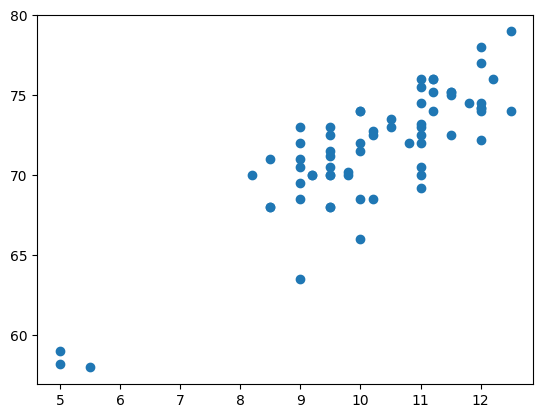

In [11]:
plt.scatter(df["beakwidth"], df["winglength"]);

In [12]:
y, X = pt.dmatrices("winglength ~ island + beakwidth", data = df) # design matricess
X[20:40]

array([[ 1. ,  1. ,  0. , 10. ],
       [ 1. ,  1. ,  0. , 10.2],
       [ 1. ,  1. ,  0. , 11. ],
       [ 1. ,  1. ,  0. , 10.5],
       [ 1. ,  1. ,  0. , 11. ],
       [ 1. ,  1. ,  0. , 10. ],
       [ 1. ,  1. ,  0. , 12. ],
       [ 1. ,  1. ,  0. , 11. ],
       [ 1. ,  1. ,  0. , 11. ],
       [ 1. ,  1. ,  0. ,  9.5],
       [ 1. ,  1. ,  0. , 11. ],
       [ 1. ,  1. ,  0. , 10.2],
       [ 1. ,  1. ,  0. , 12. ],
       [ 1. ,  1. ,  0. , 11.5],
       [ 1. ,  1. ,  0. , 11.5],
       [ 1. ,  1. ,  0. , 11.2],
       [ 1. ,  1. ,  0. , 12. ],
       [ 1. ,  1. ,  0. , 12.2],
       [ 1. ,  1. ,  0. , 12.5],
       [ 1. ,  1. ,  0. , 11.5]])

In [25]:
model = smf.ols("winglength ~ island * beakwidth", data = df)
fit = model.fit()

In [26]:
fit.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:             winglength   R-squared:                       0.771
Model:                            OLS   Adj. R-squared:                  0.753
Method:                 Least Squares   F-statistic:                     41.82
Date:                Thu, 13 Nov 2025   Prob (F-statistic):           1.30e-18
Time:                        13:49:11   Log-Likelihood:                -140.68
No. Observations:                  68   AIC:                             293.4
Df Residuals:                      62   BIC:                             306.7
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
====================================================================================================
                                       coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
Intercept                           49.0160      2.211     22.172      0.000      44.597      53.435
island[T.sancristobal]              -0.0065      3.812     -0.002      0.999      -7.627       7.615
island[T.santacruz]                 -7.6337      4.943     -1.544      0.128     -17.514       2.247
beakwidth                            2.3143      0.226     10.229      0.000       1.862       2.767
island[T.sancristobal]:beakwidth    -0.1547      0.367     -0.421      0.675      -0.889       0.579
island[T.santacruz]:beakwidth        0.5926      0.484      1.226      0.225      -0.374       1.559
==============================================================================
Omnibus:                        7.089   Durbin-Watson:                   2.007
Prob(Omnibus):                  0.029   Jarque-Bera (JB):                3.781
Skew:                          -0.362   Prob(JB):                        0.151
Kurtosis:                       2.100   Cond. No.                         256.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

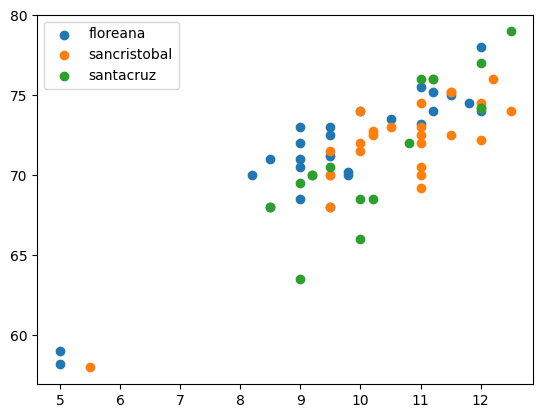

In [20]:
for name, gdf in df.groupby(["island"]):
    plt.scatter(gdf["beakwidth"], gdf["winglength"], label = name[0]);
plt.legend();

In [21]:
xnew = np.array([5, 12])
ndf = pd.DataFrame.from_dict({"beakwidth": xnew, 
                              "island": ["floreana", "floreana"]})
ndf["yhat"] = fit.predict(ndf)
ndf

,beakwidth,island,yhat
0,5,floreana,60.587695
1,12,floreana,76.788024


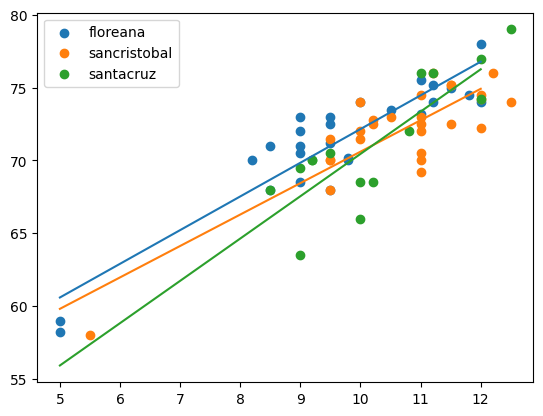

In [22]:
for name, gdf in df.groupby(["island"]):
    plt.scatter(gdf["beakwidth"], gdf["winglength"], label = name[0]);
    xnew = np.array([5, 12])
    ndf = pd.DataFrame.from_dict({"beakwidth": xnew, 
                              "island": [name[0], name[0]]})
    ndf["yhat"] = fit.predict(ndf)
    plt.plot(xnew, ndf["yhat"])
plt.legend();